# Simple CNN Classifier + LM Fusion

Train a small 1D CNN on preprocessed_dataset.pt. Maximizes P(c|sensor) × P(c|history): sensor model × n-gram LM prior.
Uses existing lm_fusion: trigram, 4-gram, or interpolated. LM fusion: fused = logits + beta * lm_log_probs.

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import numpy as np

PROJECT_ROOT = os.path.dirname(os.path.abspath('__file__'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from pretraining import load_preprocessed_dataset, get_class_weights
from src.Constants.char_to_key import CHAR_TO_INDEX, NUM_CLASSES, INDEX_TO_CHAR
from ml.models.loss_functions.custom_losses import FocalLoss
from src.visualisation.visualisation import compute_confusion_matrix_40x40, plot_virtual_keyboard_heatmap
from src.decoding.lm_fusion import build_char_ngram_lm, build_interpolated_char_lm, _lm_log_prob_dispatch

torch.manual_seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Device: {DEVICE}")

Device: mps


## Config & Load Data

In [2]:
DATA_PATH = "data_hazel_7/processed_dataset.pt"
BATCH_SIZE = 32
EPOCHS = 50
LR = 1e-3
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
# LM fusion: fused = logits + LM_BETA * log P(c|history). Aux loss weight.
LM_BETA = 0.3
LM_AUX_WEIGHT = 0.5
LM_ORDER = 3          # 2=bigram, 3=trigram, 4=4-gram
LM_USE_INTERPOLATED = True   # interpolate unigram..LM_ORDER
LM_ADD_K = 0.05

In [3]:
dataset = load_preprocessed_dataset(
    DATA_PATH,
    char_to_index=CHAR_TO_INDEX,
    is_one_hot_labels=False,
    return_class_id=False,
    add_prev_char=True,
)
print(f"Dataset: {len(dataset)} samples, input_dim={dataset.input_dim}, num_classes={NUM_CLASSES}")

Dataset: 2131 samples, input_dim=122, num_classes=40


In [4]:
n = len(dataset)
n_train = int(n * TRAIN_RATIO)
n_val = int(n * VAL_RATIO)
n_test = n - n_train - n_val

train_ds = Subset(dataset, range(0, n_train))
val_ds = Subset(dataset, range(n_train, n_train + n_val))
test_ds = Subset(dataset, range(n_train + n_val, n))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Train: 1491, Val: 319, Test: 321


## Build LM (trigram / 4-gram / interpolated)

Uses existing lm_fusion: build_char_ngram_lm or build_interpolated_char_lm.

In [5]:
# Build n-gram LM from train chars (uses existing lm_fusion)
train_chars = [dataset._labels[i] for i in range(n_train)]
if LM_USE_INTERPOLATED and LM_ORDER > 1:
    char_lm = build_interpolated_char_lm(train_chars, max_order=LM_ORDER, add_k=LM_ADD_K)
    print(f"LM: interpolated orders 1..{LM_ORDER}")
else:
    char_lm = build_char_ngram_lm(train_chars, order=LM_ORDER, add_k=LM_ADD_K)
    print(f"LM: {LM_ORDER}-gram (order={LM_ORDER})")
idx_to_char = {i: INDEX_TO_CHAR[i] for i in range(NUM_CLASSES)}

LM transition matrix: torch.Size([40, 40])


In [ ]:
def fuse_batch_logits_with_lm(logits, lm, prev_idx, beta, idx_to_char):
    """Fuse batched logits with LM. logits (B,C), prev_idx (B,). history = [prev_char] per sample."""
    if beta <= 0 or lm is None:
        return logits
    B, C = logits.shape
    lm_lp = torch.zeros_like(logits, device=logits.device)
    for b in range(B):
        prev_char = idx_to_char.get(int(prev_idx[b].item()), "")
        history = [prev_char] if prev_char else []
        for i in range(C):
            ch = idx_to_char.get(i, "")
            if ch:
                lm_lp[b, i] = _lm_log_prob_dispatch(lm, history, ch)
    return logits + beta * lm_lp

## Simple CNN Model

Acts directly on (T, D): transpose to (D, T) so features = channels, time = sequence. No projection.

In [32]:
class SimpleCNNClassifier(nn.Module):
    """1D CNN acting directly on (time, features). No projection: D features = channels, T = sequence."""
    def __init__(self, input_dim: int, num_classes: int = 40, hidden_dim: int = 64, kernel_sizes=(3, 5, 7), dropout: float = 0.2):
        super().__init__()
        # Conv1d: (B, D, T) -> each kernel slides over time axis, D is input channels
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(input_dim, hidden_dim, k, padding=k//2),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            )
            for k in kernel_sizes
        ])
        self.head = nn.Linear(hidden_dim * len(kernel_sizes), num_classes)

    def forward(self, x):
        # x: (B, T, D) -> transpose to (B, D, T): features as channels, time as sequence
        x = x.transpose(1, 2)
        conv_outputs = []
        for conv in self.convs:
            c = conv(x)
            c = F.adaptive_max_pool1d(c, 1).squeeze(-1)
            conv_outputs.append(c)
        x = torch.cat(conv_outputs, dim=-1)
        return self.head(x)

## Train

In [8]:
class_weights = get_class_weights(DATA_PATH, train_ratio=0.8, split_strategy="contiguous").to(DEVICE)
criterion = FocalLoss(gamma=2.0, alpha=class_weights)
model = SimpleCNNClassifier(input_dim=dataset.input_dim, num_classes=NUM_CLASSES, hidden_dim=64, kernel_sizes=(3, 5, 7), dropout=0.2).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

## Model Architecture

In [21]:
print(model)
print("\n" + "=" * 60)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

SimpleCNNClassifier(
  (convs): ModuleList(
    (0): Sequential(
      (0): Conv1d(122, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.2, inplace=False)
    )
    (1): Sequential(
      (0): Conv1d(122, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.2, inplace=False)
    )
    (2): Sequential(
      (0): Conv1d(122, 64, kernel_size=(7,), stride=(1,), padding=(3,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.2, inplace=False)
    )
  )
  (head): Linear(in_features=192, out_features=40, bias=True)
)

Parameters: 125,416


In [10]:
def extract_prev_idx(batch_x, num_classes=NUM_CLASSES):
    """Extract prev char index from last num_classes dims (one-hot). Zeros -> 0 (no prev)."""
    if batch_x.ndim != 3 or batch_x.shape[-1] < num_classes:
        return None
    prev_onehot = batch_x[:, 0, -num_classes:]
    return prev_onehot.argmax(dim=-1).long()

def train_epoch(model, loader, criterion, optimizer, device, lm=None, lm_beta=0.0, lm_aux_weight=0.5, idx_to_char=None):
    model.train()
    total_loss = 0.0
    for batch in loader:
        x, y = [b.to(device) for b in batch]
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        if lm_beta > 0 and lm is not None and idx_to_char is not None:
            prev_idx = extract_prev_idx(x, NUM_CLASSES)
            if prev_idx is not None:
                fused_logits = fuse_batch_logits_with_lm(logits, lm, prev_idx, lm_beta, idx_to_char)
                fused_loss = criterion(fused_logits, y)
                loss = (1.0 - lm_aux_weight) * loss + lm_aux_weight * fused_loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, criterion, device, lm=None, lm_beta=0.0, idx_to_char=None):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in loader:
            x, y = [b.to(device) for b in batch]
            logits = model(x)
            if lm_beta > 0 and lm is not None and idx_to_char is not None:
                prev_idx = extract_prev_idx(x, NUM_CLASSES)
                if prev_idx is not None:
                    logits = fuse_batch_logits_with_lm(logits, lm, prev_idx, lm_beta, idx_to_char)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            pred = logits.argmax(dim=-1)
            correct += (pred == y).sum().item()
            total += x.size(0)
    return total_loss / total if total else 0.0, correct / total if total else 0.0

In [11]:
history = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE,
                             lm=char_lm, lm_beta=LM_BETA, lm_aux_weight=LM_AUX_WEIGHT, idx_to_char=idx_to_char)
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE,
                                 lm=char_lm, lm_beta=LM_BETA, idx_to_char=idx_to_char)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}")

Epoch   1 | Train loss: 3.5521 | Val loss: 2.8717 | Val acc: 0.1191
Epoch  10 | Train loss: 0.5095 | Val loss: 2.6377 | Val acc: 0.3229
Epoch  20 | Train loss: 0.1366 | Val loss: 2.8520 | Val acc: 0.4013
Epoch  30 | Train loss: 0.0494 | Val loss: 2.9941 | Val acc: 0.4451
Epoch  40 | Train loss: 0.0330 | Val loss: 3.0995 | Val acc: 0.4828
Epoch  50 | Train loss: 0.0301 | Val loss: 3.0658 | Val acc: 0.5204


## Results

In [12]:
test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE,
                               lm=char_lm, lm_beta=LM_BETA, idx_to_char=idx_to_char)

print("=" * 60)
print("Simple CNN Classifier + LM Fusion Results (Focal Loss)")
print("=" * 60)
print(f"Focal Loss (gamma=2.0):")
print(f"  Val loss:  {history['val_loss'][-1]:.4f}")
print(f"  Test loss: {test_loss:.4f}")
print(f"Character accuracy:")
print(f"  Val acc:  {history['val_acc'][-1]:.4f} ({history['val_acc'][-1]*100:.2f}%)")
print(f"  Test acc: {test_acc:.4f} ({test_acc*100:.2f}%)")
print("=" * 60)

Simple CNN Classifier + LM Fusion Results (Focal Loss)
Focal Loss (gamma=2.0):
  Val loss:  3.0658
  Test loss: 3.4057
Character accuracy:
  Val acc:  0.5204 (52.04%)
  Test acc: 0.4673 (46.73%)


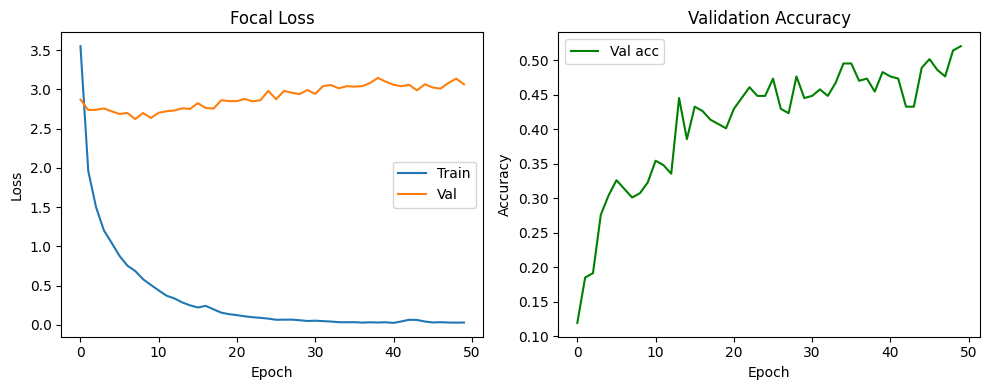

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].set_title("Focal Loss")
axes[1].plot(history["val_acc"], label="Val acc", color="green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].set_title("Validation Accuracy")
plt.tight_layout()
plt.show()

## Keyboard Heatmap

In [26]:
cm_test = compute_confusion_matrix_40x40(test_ds, model, DEVICE, coord_dict=None)

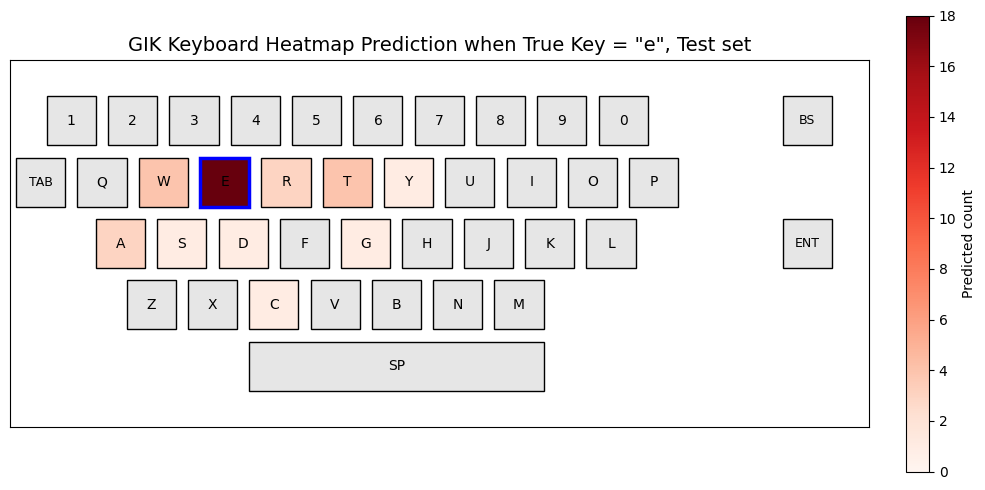

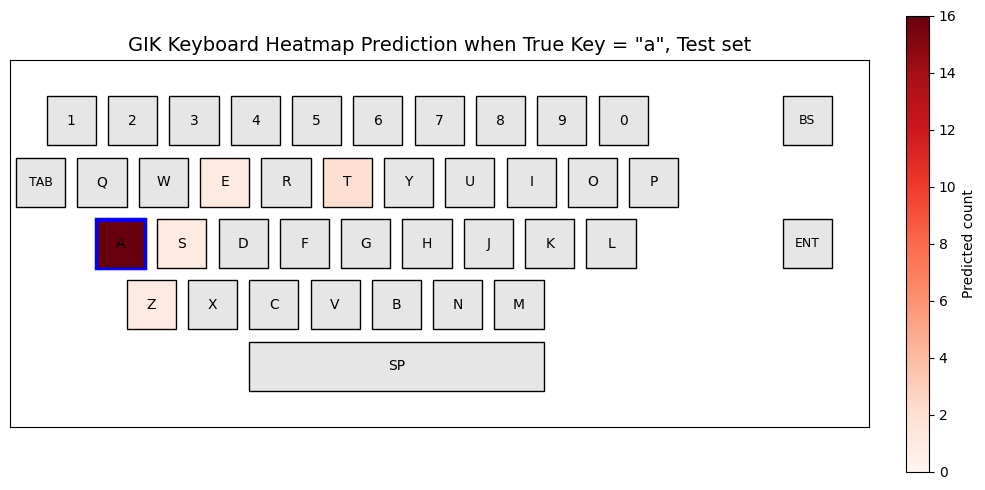

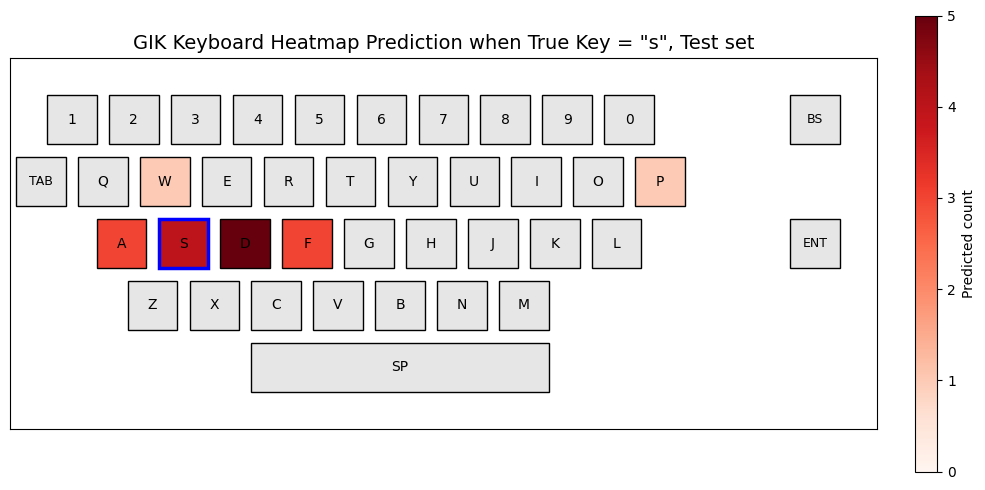

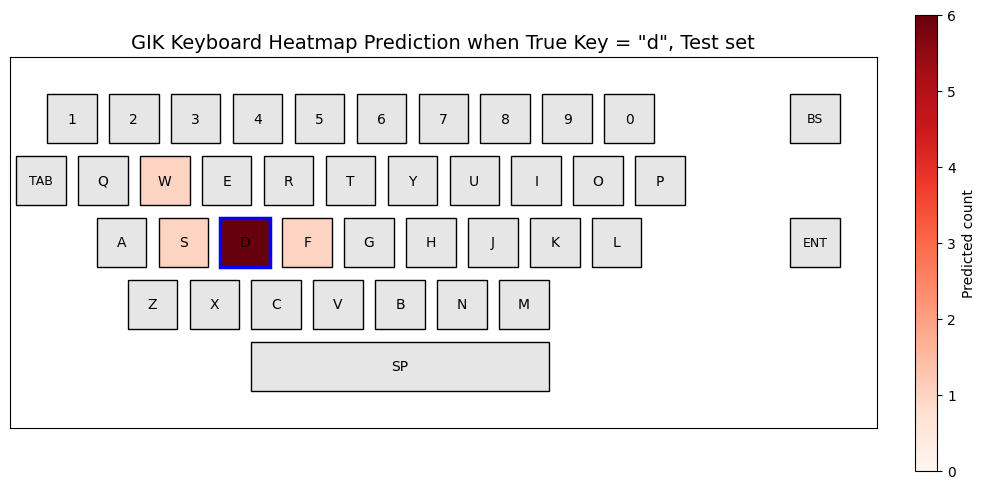

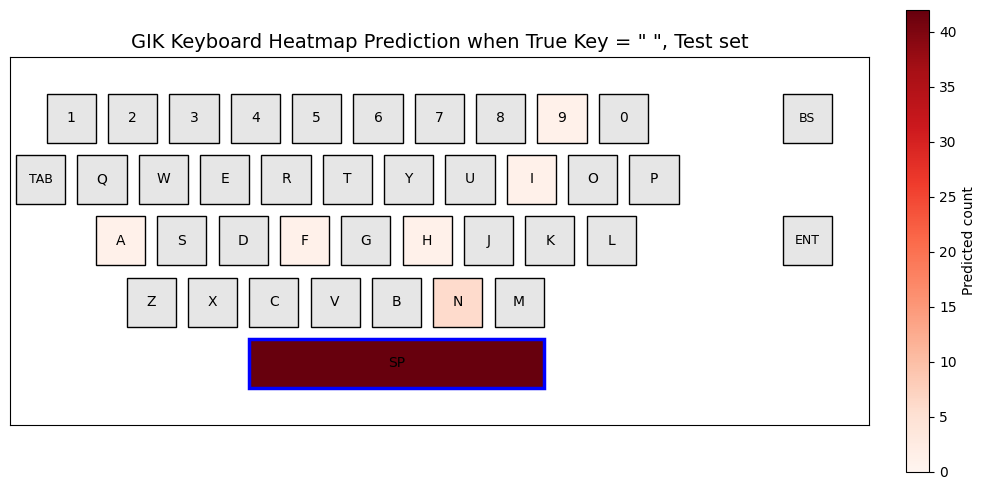

In [40]:
for anchor in ['e', 'a', 's', 'd', ' ']:
    plot_virtual_keyboard_heatmap(cm_test, anchor, 'Test')